In [ ]:
# Read in politicians.csv
import pandas as pd

In [90]:
import pandas as pd
import os

# ── Config ────────────────────────────────────────────────────────────────────
OUTPUT   = "politicians.csv"
ENCODING = "utf-8-sig"

# ── Load & combine ────────────────────────────────────────────────────────────
csv_files = [
    r"C:\Users\nyafe\Downloads\query.csv",
    r"C:\Users\nyafe\Downloads\query (1).csv",
    r"C:\Users\nyafe\Downloads\query (2).csv",
    r"C:\Users\nyafe\Downloads\query (3).csv",
    r"C:\Users\nyafe\Downloads\query (4).csv",
    r"C:\Users\nyafe\Downloads\query (5).csv",
    r"C:\Users\nyafe\Downloads\query (6).csv",
    r"C:\Users\nyafe\Downloads\query (7).csv",
    r"C:\Users\nyafe\Downloads\query (8).csv",
    r"C:\Users\nyafe\Downloads\query (9).csv",
    r"C:\Users\nyafe\Downloads\query (10).csv",
]

print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    df = pd.read_csv(f, encoding="utf-8-sig", dtype=str)
    df["source_file"] = os.path.basename(f)
    dfs.append(df)

wikidf = pd.concat(dfs, ignore_index=True)
print(f"Total rows before dedup: {len(wikidf)}")

# ── Step 1: Assign Country & Branch from source file ─────────────────────────
def extract_country(source_file):
    if source_file in ["query.csv", "query (1).csv", "query (2).csv", "query (3).csv", "query (10).csv"]:
        return "United States"
    elif source_file in ["query (4).csv", "query (5).csv"]:
        return "Germany"
    elif source_file in ["query (6).csv", "query (7).csv"]:
        return "Italy"
    else:
        return "Poland"

branch_map = {
    "query.csv":      "Executive",    # US Cabinet
    "query (1).csv":  "Legislative",  # US House A-M
    "query (2).csv":  "Legislative",  # US House N-Z
    "query (3).csv":  "Legislative",  # US Senate A-M
    "query (4).csv":  "Legislative",  # US Senate N-Z
    "query (5).csv":  "Executive",    # Germany Executive
    "query (6).csv":  "Legislative",  # Germany Legislative
    "query (7).csv":  "Executive",    # Italy Executive
    "query (8).csv":  "Legislative",  # Italy Legislative
    "query (9).csv":  "Executive",    # Poland Executive
    "query (10).csv": "Legislative",  # Poland Legislative
}

wikidf["Country"] = wikidf["source_file"].apply(extract_country)
wikidf["Branch"]  = wikidf["source_file"].map(branch_map)

# ── Step 2: Rename & drop duplicate columns ───────────────────────────────────
wikidf.rename(columns={"positionLabel": "Position"}, inplace=True)
wikidf = wikidf.loc[:, ~wikidf.columns.duplicated(keep="first")]

# ── Step 3: Deduplicate ───────────────────────────────────────────────────────
dedup_on = [c for c in ["Name", "Position", "YearTookOffice"] if c in wikidf.columns]
wikidf.drop_duplicates(subset=dedup_on, keep="first", inplace=True)
print(f"Total rows after dedup:  {len(wikidf)}")

# ── Step 4: Select expected columns ──────────────────────────────────────────
EXPECTED_COLS = [
    "Name", "Gender", "Country", "Party", "Position",
    "Branch", "YearTookOffice", "YearLeftOffice", "Status",
    "Twitter", "source_file"
]
for col in EXPECTED_COLS:
    if col not in wikidf.columns:
        wikidf[col] = ""
wikidf = wikidf[EXPECTED_COLS]

# ── Step 5: Clean ─────────────────────────────────────────────────────────────
wikidf["Name"]   = wikidf["Name"].str.strip()
wikidf["Party"]  = wikidf["Party"].str.strip("[]'\" ").str.split(",").str[0].str.strip()
wikidf["Gender"] = wikidf["Gender"].str.strip("[]'\" ").str.split(",").str[0].str.strip().str.capitalize()
wikidf["Status"] = wikidf["Status"].str.strip("[]'\" ").str.split(",").str[0].str.strip()
wikidf["Status"] = wikidf["Status"].replace("", "Unknown").fillna("Current")
wikidf = wikidf[wikidf["Status"].isin(["Current", "Former", "Unknown"])]

# Remove historical parties
historical_parties = ["Whig", "Federalist", "Democratic-Republican", "National Republican", "Anti-Masonic"]
wikidf = wikidf[~wikidf["Party"].isin(historical_parties)]

# Remove ghost records
wikidf["YearTookOffice"] = pd.to_numeric(wikidf["YearTookOffice"], errors="coerce")
wikidf["YearLeftOffice"] = pd.to_numeric(wikidf["YearLeftOffice"], errors="coerce")
wikidf = wikidf[~(
    (wikidf["YearTookOffice"] < 1990) &
    (wikidf["YearLeftOffice"].isna() | (wikidf["YearLeftOffice"] < 2021))
)]
wikidf = wikidf[wikidf["YearLeftOffice"].isna() | (wikidf["YearLeftOffice"] >= 2021)]
wikidf["YearTookOffice"] = wikidf["YearTookOffice"].astype("Int64")
wikidf["YearLeftOffice"] = wikidf["YearLeftOffice"].astype("Int64")

# ── Step 6: Sort & save ───────────────────────────────────────────────────────
wikidf.sort_values(["Country", "Branch", "Name"], inplace=True)
wikidf.to_csv(OUTPUT, index=False, encoding=ENCODING)
print(f"\n✅ Saved to '{OUTPUT}' — {len(wikidf)} rows, {len(wikidf.columns)} columns")
print("\nRow counts by Country + Branch:")
print(wikidf.groupby(["Country", "Branch"]).size().to_string())
print(f"\nTwitter handle coverage: {wikidf['Twitter'].notna().sum()} / {len(wikidf)} rows")

Found 11 CSV files
Total rows before dedup: 19162
Total rows after dedup:  16750

✅ Saved to 'politicians.csv' — 16639 rows, 11 columns

Row counts by Country + Branch:
Country        Branch     
Germany        Executive        57
               Legislative    2146
Italy          Executive        13
               Legislative    1410
Poland         Executive        41
               Legislative    2238
United States  Executive      6898
               Legislative    3836

Twitter handle coverage: 4124 / 16639 rows


In [91]:
wikidf.columns

Index(['Name', 'Gender', 'Country', 'Party', 'Position', 'Branch',
       'YearTookOffice', 'YearLeftOffice', 'Status', 'Twitter', 'source_file'],
      dtype='object')

In [92]:
print(wikidf["source_file"].value_counts())

source_file
query.csv         6898
query (1).csv     3013
query (8).csv     2238
query (4).csv     2146
query (6).csv     1410
query (10).csv     476
query (2).csv      244
query (3).csv      103
query (5).csv       57
query (9).csv       41
query (7).csv       13
Name: count, dtype: int64


In [95]:
# # Drop source_file since we don't need it anymore
wikidf = wikidf.drop(columns=["source_file"])

In [96]:
print(wikidf["Branch"].value_counts())

Branch
Legislative    9630
Executive      7009
Name: count, dtype: int64


C:\Users\nyafe\AppData\Local\Temp\ipykernel_23308\4224553700.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Count", data=country_counts, palette="viridis")


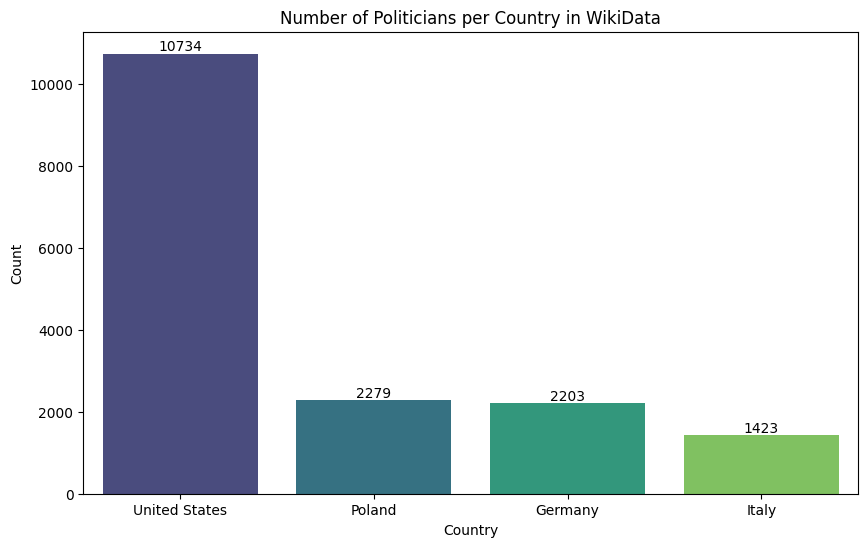

In [97]:
# Graph how many politicians we have per country with numnber count
# Add count to the top of each bar
import matplotlib.pyplot as plt
import seaborn as sns
# Count number of politicians per country
country_counts = wikidf["Country"].value_counts().reset_index()
country_counts.columns = ["Country", "Count"]
# Single bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x="Country", y="Count", data=country_counts, palette="viridis")
plt.title("Number of Politicians per Country in WikiData")
plt.xlabel("Country")
plt.ylabel("Count")
# Add count to the top of each bar
for index, row in country_counts.iterrows():
    plt.text(index, row["Count"], row["Count"], color="black", ha="center", va="bottom")
plt.show()

C:\Users\nyafe\AppData\Local\Temp\ipykernel_23308\2445977265.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Twitter_Percentage", data=twitter_percentage, palette="viridis")


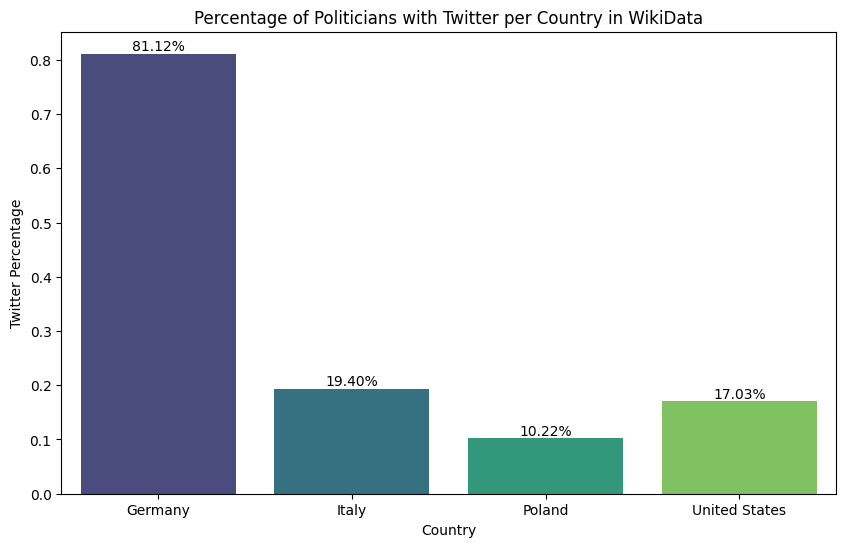

In [98]:
# Percentage with "Twitter" per country
wikidf["Has_Twitter"] = wikidf["Twitter"].notna()
twitter_percentage = wikidf.groupby("Country")["Has_Twitter"].mean().reset_index()
twitter_percentage.columns = ["Country", "Twitter_Percentage"]
# Bar chart for Twitter percentage
plt.figure(figsize=(10, 6))
sns.barplot(x="Country", y="Twitter_Percentage", data=twitter_percentage, palette="viridis")
plt.title("Percentage of Politicians with Twitter per Country in WikiData")
plt.xlabel("Country")
plt.ylabel("Twitter Percentage")
# Add percentage to the top of each bar
for index, row in twitter_percentage.iterrows():
    plt.text(index, row["Twitter_Percentage"], f"{row['Twitter_Percentage']:.2%}", color="black", ha="center", va="bottom")
plt.show()

C:\Users\nyafe\AppData\Local\Temp\ipykernel_23308\2601024724.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Twitter_Count", data=twitter_counts, palette="viridis")


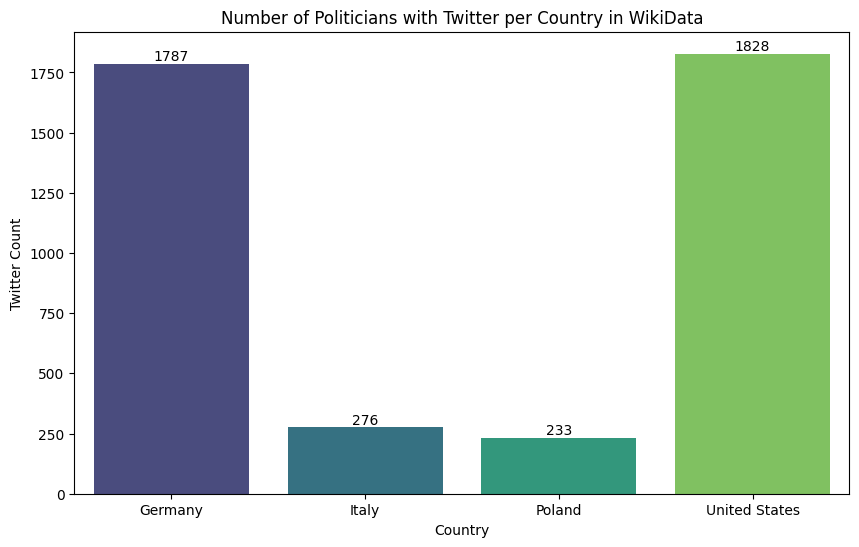

In [99]:
# Counts of politicians with Twitter per country
twitter_counts = wikidf[wikidf["Has_Twitter"]].groupby("Country").size().reset_index(name="Twitter_Count")
# Bar chart for Twitter counts
plt.figure(figsize=(10, 6))
sns.barplot(x="Country", y="Twitter_Count", data=twitter_counts, palette="viridis")
plt.title("Number of Politicians with Twitter per Country in WikiData")
plt.xlabel("Country")
plt.ylabel("Twitter Count")
# Add count to the top of each bar
for index, row in twitter_counts.iterrows():
    plt.text(index, row["Twitter_Count"], row["Twitter_Count"], color="black", ha="center", va="bottom")
plt.show()

C:\Users\nyafe\AppData\Local\Temp\ipykernel_23308\404143199.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Current_Twitter_Percentage", data=current_twitter_percentage, palette="viridis")


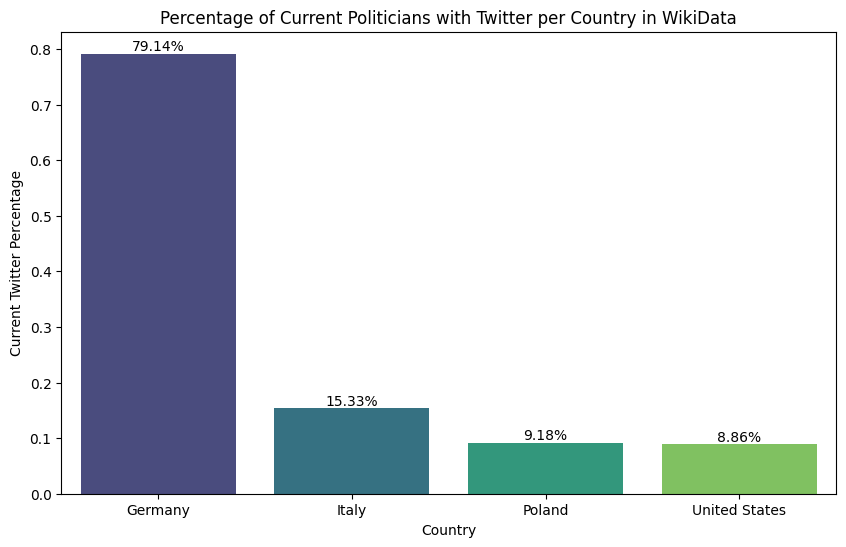

In [100]:
# Percentage of "Status = "Current" with Twitter per Country in WikiData
wikidf["Status"] = wikidf["Status"].str.strip("[]'\" ").str.split(",").str[0].str.strip()
current_twitter_percentage = wikidf[wikidf["Status"] == "Current"].groupby("Country")["Has_Twitter"].mean().reset_index()
current_twitter_percentage.columns = ["Country", "Current_Twitter_Percentage"]
# Bar chart for Current Twitter percentage
plt.figure(figsize=(10, 6))
sns.barplot(x="Country", y="Current_Twitter_Percentage", data=current_twitter_percentage, palette="viridis")
plt.title("Percentage of Current Politicians with Twitter per Country in WikiData")
plt.xlabel("Country")
plt.ylabel("Current Twitter Percentage")
# Add percentage to the top of each bar
for index, row in current_twitter_percentage.iterrows():
    plt.text(index, row["Current_Twitter_Percentage"], f"{row['Current_Twitter_Percentage']:.2%}", color="black", ha="center", va="bottom")
plt.show()

C:\Users\nyafe\AppData\Local\Temp\ipykernel_23308\383741467.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Current_Twitter_Count", data=current_twitter_counts, palette="viridis")


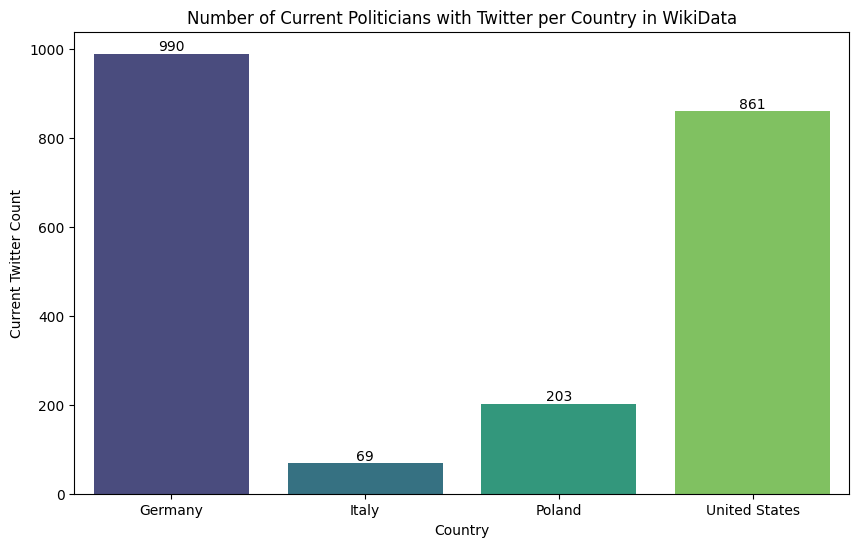

In [101]:
# Count of Stauts = Current with Twitter per Country in WikiData
current_twitter_counts = wikidf[wikidf["Status"] == "Current"].groupby("Country")["Has_Twitter"].sum().reset_index(name="Current_Twitter_Count")
# Bar chart for Current Twitter counts
plt.figure(figsize=(10, 6))
sns.barplot(x="Country", y="Current_Twitter_Count", data=current_twitter_counts, palette="viridis")
plt.title("Number of Current Politicians with Twitter per Country in WikiData")
plt.xlabel("Country")
plt.ylabel("Current Twitter Count")
# Add count to the top of each bar
for index, row in current_twitter_counts.iterrows():
    plt.text(index, row["Current_Twitter_Count"], row["Current_Twitter_Count"], color="black", ha="center", va="bottom")
plt.show()


C:\Users\nyafe\AppData\Local\Temp\ipykernel_23308\3123377633.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(2) if x.name == "United States" else x.head(5))
C:\Users\nyafe\AppData\Local\Temp\ipykernel_23308\3123377633.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Party", y="Twitter_Percentage", data=data, palette="viridis", ax=ax)
C:\Users\nyafe\AppData\Local\Temp\ipykernel_23308\3123377633.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

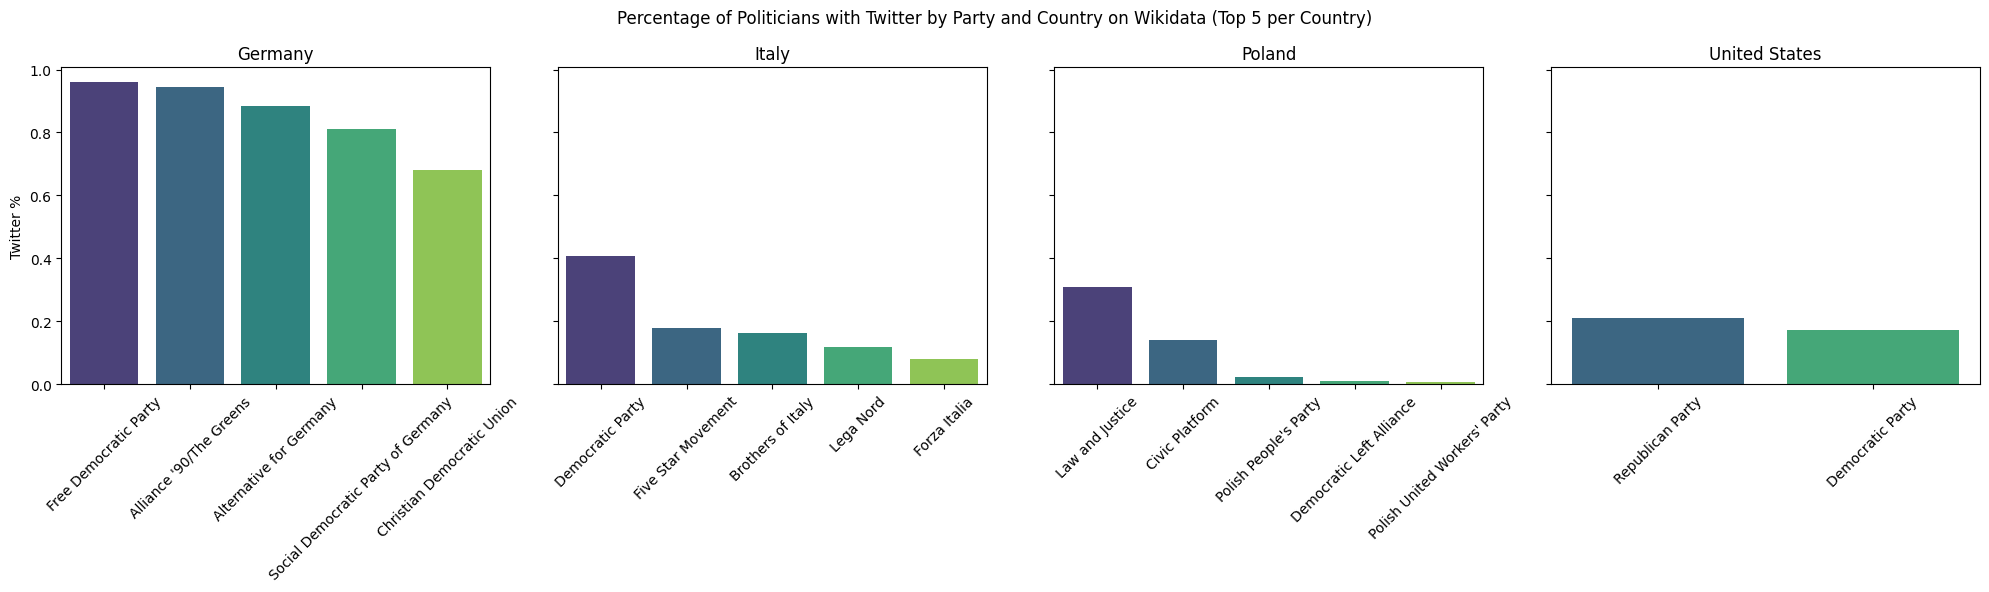

In [102]:
# Top 5 parties per country by number of politicians
top_parties = (
    wikidf.groupby(["Country", "Party"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .groupby("Country")
    .apply(lambda x: x.head(2) if x.name == "United States" else x.head(5))
    .reset_index(drop=True)
)

filtered = wikidf.merge(top_parties[["Country", "Party"]], on=["Country", "Party"])

party_twitter_percentage = (
    filtered.groupby(["Country", "Party"])["Has_Twitter"]
    .mean()
    .reset_index()
)
party_twitter_percentage.columns = ["Country", "Party", "Twitter_Percentage"]

# One subplot per country
countries = party_twitter_percentage["Country"].unique()
fig, axes = plt.subplots(1, len(countries), figsize=(20, 6), sharey=True)

for ax, country in zip(axes, countries):
    data = (
        party_twitter_percentage[party_twitter_percentage["Country"] == country]
        .sort_values("Twitter_Percentage", ascending=False)
    )
    sns.barplot(x="Party", y="Twitter_Percentage", data=data, palette="viridis", ax=ax)
    ax.set_title(country)
    ax.set_xlabel("")
    ax.set_ylabel("Twitter %" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Percentage of Politicians with Twitter by Party and Country on Wikidata (Top 5 per Country)")
plt.tight_layout()
plt.show()

In [103]:
# Save the wikidf as a csv
wikidf.to_csv(r"C:\Users\nyafe\Downloads\wikidata_politicians_cleaned.csv", index=False)


In [104]:
import pandas as pd
df = pd.read_csv(r"C:\Users\nyafe\Downloads\universal_set.csv", nrows=2)
print(df.columns.tolist())

['Name', 'Gender', 'Country', 'Party', 'Position', 'Branch', 'Role', 'YearTookOffice', 'Status', 'Region']


In [36]:
! pip install rapidfuzz


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [105]:
UNIVERSAL_FILE = r"C:\Users\nyafe\Downloads\universal.csv"  # ← your actual path
UNIV_NAME_COL  = "Name"                                     # ← your actual column name

In [106]:
import pandas as pd
from rapidfuzz import process, fuzz
import unicodedata

# ── Config ────────────────────────────────────────────────────────────────────
WIKIDATA_FILE  = r"C:\Users\nyafe\Downloads\wikidata_politicians_cleaned.csv"
UNIVERSAL_FILE = r"C:\Users\nyafe\Downloads\universal_set.csv"   # ← update this
OUTPUT_MATCHED    = "matched.csv"        # rows that matched in both sets
OUTPUT_WIKI_ONLY  = "wikidata_only.csv"  # in wikidata but not universal
OUTPUT_UNIV_ONLY  = "universal_only.csv" # in universal but not wikidata
THRESHOLD = 90

# Column name for the name field in each file — change if yours differ
WIKI_NAME_COL = "Name"
UNIV_NAME_COL = "Name"                   # ← update this if different

# ── Helpers ───────────────────────────────────────────────────────────────────
def normalize(s):
    """Lowercase, strip, and remove diacritics for comparison."""
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKD", s)
    s = s.encode("ascii", "ignore").decode("ascii")
    return s.lower().strip()

def strip_middle(s):
    """'John A. Smith' → 'John Smith' to help match middle-initial variants."""
    parts = s.split()
    return " ".join(p for p in parts if not (len(p) <= 2 and p.endswith(".")))

# ── Load data ─────────────────────────────────────────────────────────────────
wiki = pd.read_csv(WIKIDATA_FILE, dtype=str, encoding="utf-8-sig").fillna("")
univ = pd.read_csv(UNIVERSAL_FILE, dtype=str, encoding="utf-8-sig").fillna("")

print(f"Wikidata rows:   {len(wiki)}")
print(f"Universal rows:  {len(univ)}")

# Prefix universal columns to avoid collisions on merge
univ_renamed = univ.copy()
univ_renamed.columns = [
    f"univ_{c}" if c != UNIV_NAME_COL else UNIV_NAME_COL
    for c in univ.columns
]

# ── Prepare normalized name lists ─────────────────────────────────────────────
wiki["_norm"] = wiki[WIKI_NAME_COL].apply(lambda x: normalize(strip_middle(x)))
univ["_norm"] = univ[UNIV_NAME_COL].apply(lambda x: normalize(strip_middle(x)))

univ_norm_list = univ["_norm"].tolist()

# ── Fuzzy match ───────────────────────────────────────────────────────────────
print(f"\nRunning fuzzy match at threshold {THRESHOLD}...")

match_names   = []
match_scores  = []
match_indices = []

for norm_name in wiki["_norm"]:
    result = process.extractOne(
        norm_name,
        univ_norm_list,
        scorer=fuzz.token_sort_ratio,
        score_cutoff=THRESHOLD
    )
    if result:
        match_names.append(result[0])
        match_scores.append(result[1])
        match_indices.append(result[2])
    else:
        match_names.append(None)
        match_scores.append(None)
        match_indices.append(None)

wiki["_match_norm"]  = match_names
wiki["_match_score"] = match_scores
wiki["_match_idx"]   = match_indices

# ── Split into matched / unmatched ────────────────────────────────────────────
matched_wiki   = wiki[wiki["_match_idx"].notna()].copy()
unmatched_wiki = wiki[wiki["_match_idx"].isna()].copy()

matched_univ_indices = set(matched_wiki["_match_idx"].dropna().astype(int).tolist())
unmatched_univ = univ[~univ.index.isin(matched_univ_indices)].copy()

# ── Merge matched rows with universal data ────────────────────────────────────
matched_wiki["_match_idx"] = matched_wiki["_match_idx"].astype(int)
univ_renamed.index = univ.index

merged = matched_wiki.merge(
    univ_renamed.drop(columns=[UNIV_NAME_COL]),
    left_on="_match_idx",
    right_index=True,
    how="left"
)

# ── Clean up internal columns ─────────────────────────────────────────────────
drop_cols = ["_norm", "_match_norm", "_match_idx"]
merged.drop(columns=drop_cols, inplace=True, errors="ignore")
unmatched_wiki.drop(columns=drop_cols + ["_match_score"], inplace=True, errors="ignore")
unmatched_univ.drop(columns=["_norm"], inplace=True, errors="ignore")

merged.rename(columns={"_match_score": "match_score"}, inplace=True)

# ── Save outputs ──────────────────────────────────────────────────────────────
merged.to_csv(OUTPUT_MATCHED, index=False, encoding="utf-8-sig")
unmatched_wiki.to_csv(OUTPUT_WIKI_ONLY, index=False, encoding="utf-8-sig")
unmatched_univ.to_csv(OUTPUT_UNIV_ONLY, index=False, encoding="utf-8-sig")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n✅ Done!")
print(f"  Matched (in both):       {len(merged)} rows  → {OUTPUT_MATCHED}")
print(f"  Wikidata only:           {len(unmatched_wiki)} rows  → {OUTPUT_WIKI_ONLY}")
print(f"  Universal only:          {len(unmatched_univ)} rows  → {OUTPUT_UNIV_ONLY}")
print(f"\nMatch rate: {len(merged) / len(wiki) * 100:.1f}% of Wikidata rows matched")

Wikidata rows:   16639
Universal rows:  4218

Running fuzzy match at threshold 90...

✅ Done!
  Matched (in both):       4653 rows  → matched.csv
  Wikidata only:           11986 rows  → wikidata_only.csv
  Universal only:          1266 rows  → universal_only.csv

Match rate: 28.0% of Wikidata rows matched


In [107]:
import pandas as pd
from rapidfuzz import process, fuzz
import unicodedata

# ── Config ────────────────────────────────────────────────────────────────────
WIKIDATA_FILE  = r"C:\Users\nyafe\Downloads\wikidata_politicians_cleaned.csv"
UNIVERSAL_FILE = r"C:\Users\nyafe\Downloads\universal_set.csv"   # ← update this
OUTPUT_MATCHED    = "matched.csv"        # rows that matched in both sets
OUTPUT_WIKI_ONLY  = "wikidata_only.csv"  # in wikidata but not universal
OUTPUT_UNIV_ONLY  = "universal_only.csv" # in universal but not wikidata
THRESHOLD = 80 # LOWER THRESHOLD

# Column name for the name field in each file — change if yours differ
WIKI_NAME_COL = "Name"
UNIV_NAME_COL = "Name"                   # ← update this if different

# ── Helpers ───────────────────────────────────────────────────────────────────
def normalize(s):
    """Lowercase, strip, and remove diacritics for comparison."""
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKD", s)
    s = s.encode("ascii", "ignore").decode("ascii")
    return s.lower().strip()

def strip_middle(s):
    """'John A. Smith' → 'John Smith' to help match middle-initial variants."""
    parts = s.split()
    return " ".join(p for p in parts if not (len(p) <= 2 and p.endswith(".")))

# ── Load data ─────────────────────────────────────────────────────────────────
wiki = pd.read_csv(WIKIDATA_FILE, dtype=str, encoding="utf-8-sig").fillna("")
univ = pd.read_csv(UNIVERSAL_FILE, dtype=str, encoding="utf-8-sig").fillna("")

print(f"Wikidata rows:   {len(wiki)}")
print(f"Universal rows:  {len(univ)}")

# Prefix universal columns to avoid collisions on merge
univ_renamed = univ.copy()
univ_renamed.columns = [
    f"univ_{c}" if c != UNIV_NAME_COL else UNIV_NAME_COL
    for c in univ.columns
]

# ── Prepare normalized name lists ─────────────────────────────────────────────
wiki["_norm"] = wiki[WIKI_NAME_COL].apply(lambda x: normalize(strip_middle(x)))
univ["_norm"] = univ[UNIV_NAME_COL].apply(lambda x: normalize(strip_middle(x)))

univ_norm_list = univ["_norm"].tolist()

# ── Fuzzy match ───────────────────────────────────────────────────────────────
print(f"\nRunning fuzzy match at threshold {THRESHOLD}...")

match_names   = []
match_scores  = []
match_indices = []

for norm_name in wiki["_norm"]:
    result = process.extractOne(
        norm_name,
        univ_norm_list,
        scorer=fuzz.token_sort_ratio,
        score_cutoff=THRESHOLD
    )
    if result:
        match_names.append(result[0])
        match_scores.append(result[1])
        match_indices.append(result[2])
    else:
        match_names.append(None)
        match_scores.append(None)
        match_indices.append(None)

wiki["_match_norm"]  = match_names
wiki["_match_score"] = match_scores
wiki["_match_idx"]   = match_indices

# ── Split into matched / unmatched ────────────────────────────────────────────
matched_wiki   = wiki[wiki["_match_idx"].notna()].copy()
unmatched_wiki = wiki[wiki["_match_idx"].isna()].copy()

matched_univ_indices = set(matched_wiki["_match_idx"].dropna().astype(int).tolist())
unmatched_univ = univ[~univ.index.isin(matched_univ_indices)].copy()

# ── Merge matched rows with universal data ────────────────────────────────────
matched_wiki["_match_idx"] = matched_wiki["_match_idx"].astype(int)
univ_renamed.index = univ.index

merged = matched_wiki.merge(
    univ_renamed.drop(columns=[UNIV_NAME_COL]),
    left_on="_match_idx",
    right_index=True,
    how="left"
)

# ── Clean up internal columns ─────────────────────────────────────────────────
drop_cols = ["_norm", "_match_norm", "_match_idx"]
merged.drop(columns=drop_cols, inplace=True, errors="ignore")
unmatched_wiki.drop(columns=drop_cols + ["_match_score"], inplace=True, errors="ignore")
unmatched_univ.drop(columns=["_norm"], inplace=True, errors="ignore")

merged.rename(columns={"_match_score": "match_score"}, inplace=True)

# ── Save outputs ──────────────────────────────────────────────────────────────
merged.to_csv(OUTPUT_MATCHED, index=False, encoding="utf-8-sig")
unmatched_wiki.to_csv(OUTPUT_WIKI_ONLY, index=False, encoding="utf-8-sig")
unmatched_univ.to_csv(OUTPUT_UNIV_ONLY, index=False, encoding="utf-8-sig")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n✅ Done!")
print(f"  Matched (in both):       {len(merged)} rows  → {OUTPUT_MATCHED}")
print(f"  Wikidata only:           {len(unmatched_wiki)} rows  → {OUTPUT_WIKI_ONLY}")
print(f"  Universal only:          {len(unmatched_univ)} rows  → {OUTPUT_UNIV_ONLY}")
print(f"\nMatch rate: {len(merged) / len(wiki) * 100:.1f}% of Wikidata rows matched")

Wikidata rows:   16639
Universal rows:  4218

Running fuzzy match at threshold 80...

✅ Done!
  Matched (in both):       5522 rows  → matched.csv
  Wikidata only:           11117 rows  → wikidata_only.csv
  Universal only:          1088 rows  → universal_only.csv

Match rate: 33.2% of Wikidata rows matched
